# Load Preprocessed Data

(303, 14)
Missing values per column:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64

Total missing values: 6
Missing values after imputation: 0
Categorical columns: ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']
Data types:
age         float64
sex         float64
cp          float64
trestbps    float64
chol        float64
fbs         float64
restecg     float64
thalach     float64
exang       float64
oldpeak     float64
slope       float64
ca          float64
thal        float64
target      float64
dtype: object
Categorical columns: ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']
Numerical columns: ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
Shape after encoding: (303, 21)
New columns created:
['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'target', 'sex_1.0', 'cp_2.0', 'cp_3.0', 'cp_4

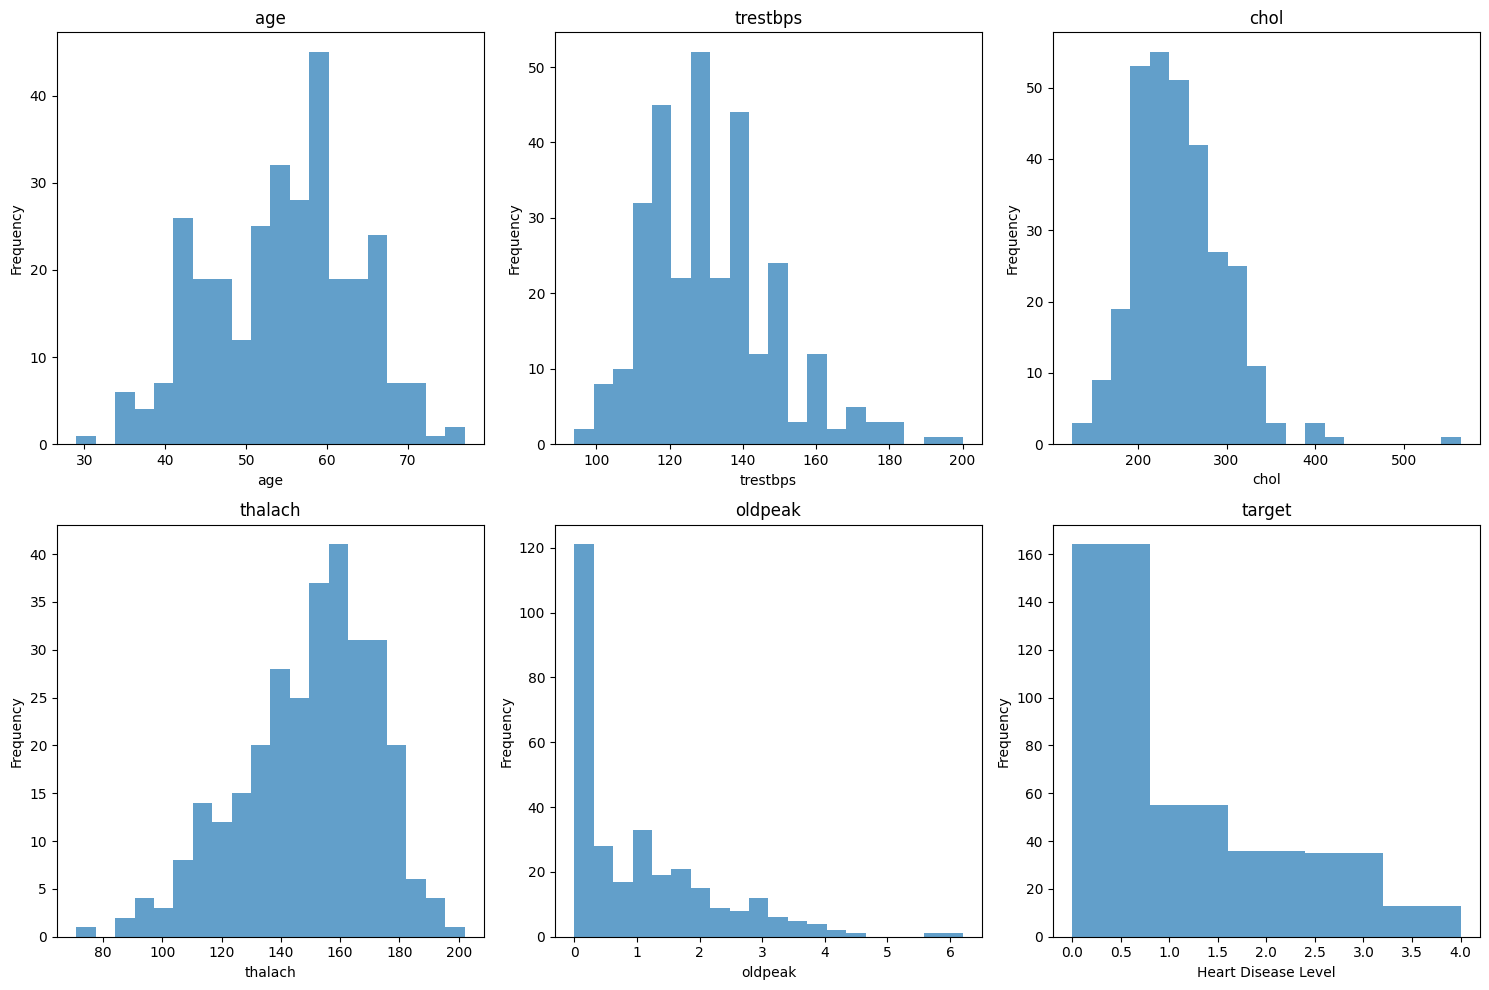

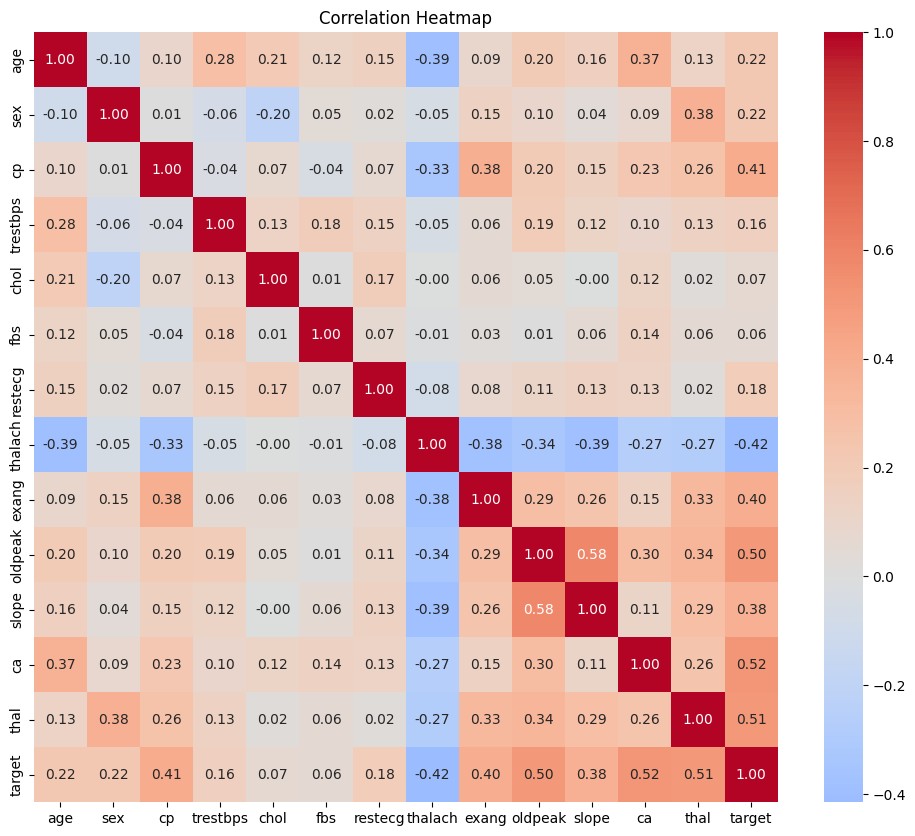

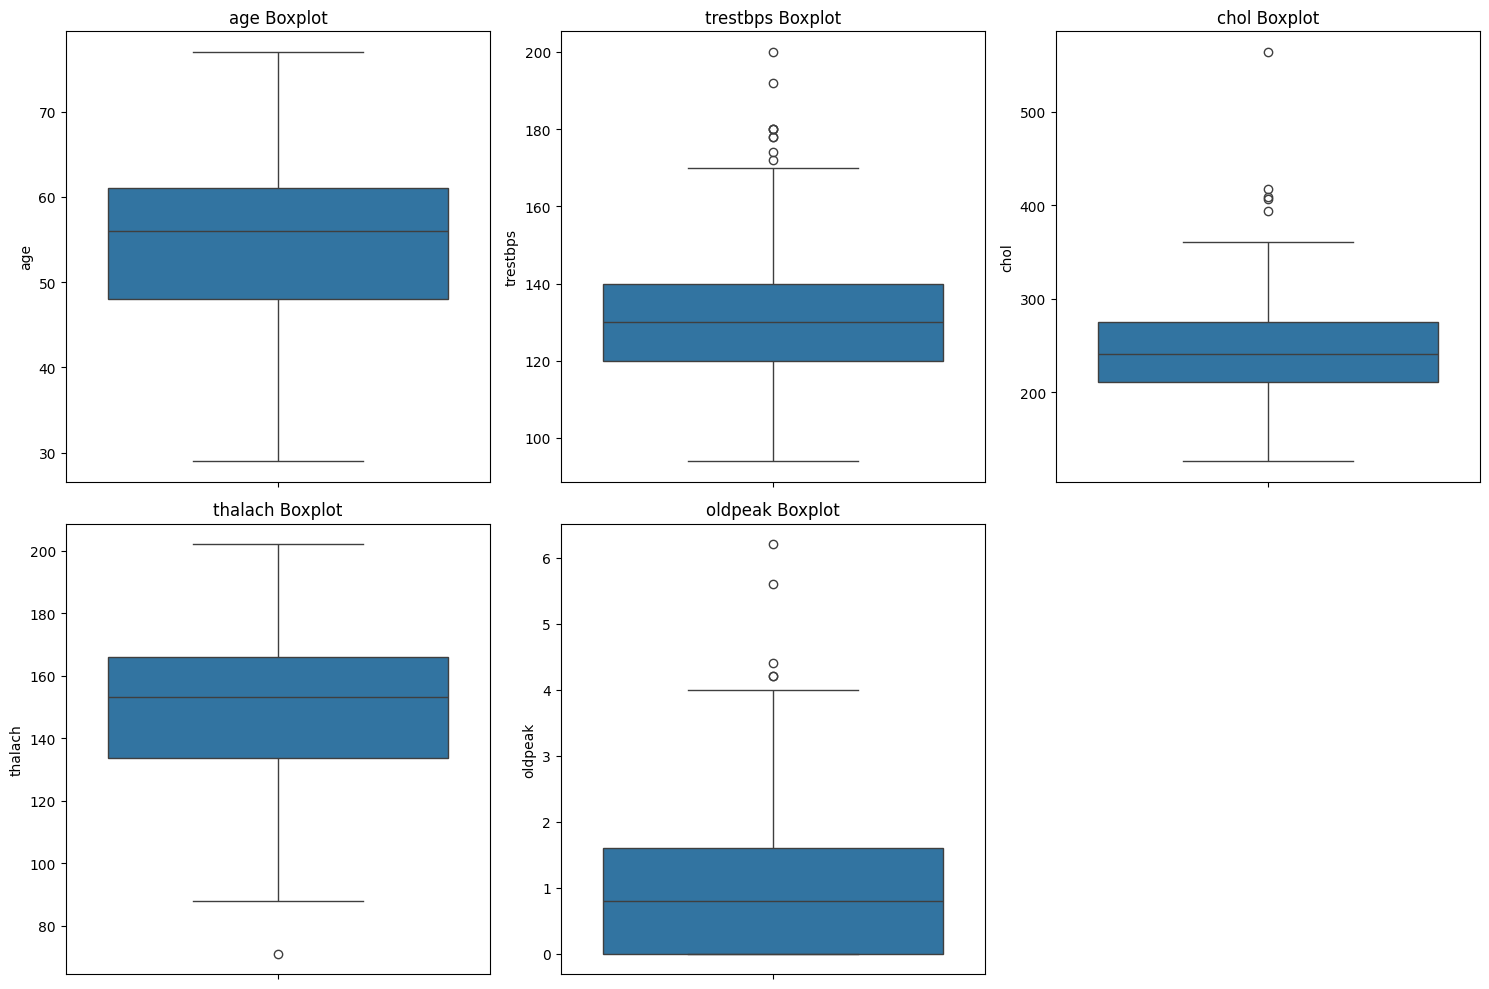

Random Forest Feature Importance:
        feature  importance
3       thalach    0.145161
4       oldpeak    0.119441
0           age    0.114960
2          chol    0.110535
1      trestbps    0.096552
19     thal_7.0    0.060592
8        cp_4.0    0.058923
12    exang_1.0    0.047135
13    slope_2.0    0.034934
15       ca_1.0    0.034681
5       sex_1.0    0.032970
16       ca_2.0    0.031061
11  restecg_2.0    0.024380
17       ca_3.0    0.020094
9       fbs_1.0    0.018563
7        cp_3.0    0.016859
18     thal_6.0    0.012417
6        cp_2.0    0.009235
14    slope_3.0    0.008491
10  restecg_1.0    0.003017
XGBoost Feature Importance:
        feature  importance
8        cp_4.0    0.178133
19     thal_7.0    0.111019
14    slope_3.0    0.110085
15       ca_1.0    0.066373
16       ca_2.0    0.059842
17       ca_3.0    0.054655
18     thal_6.0    0.050118
4       oldpeak    0.045579
5       sex_1.0    0.041722
3       thalach    0.040518
12    exang_1.0    0.039136
0           ag

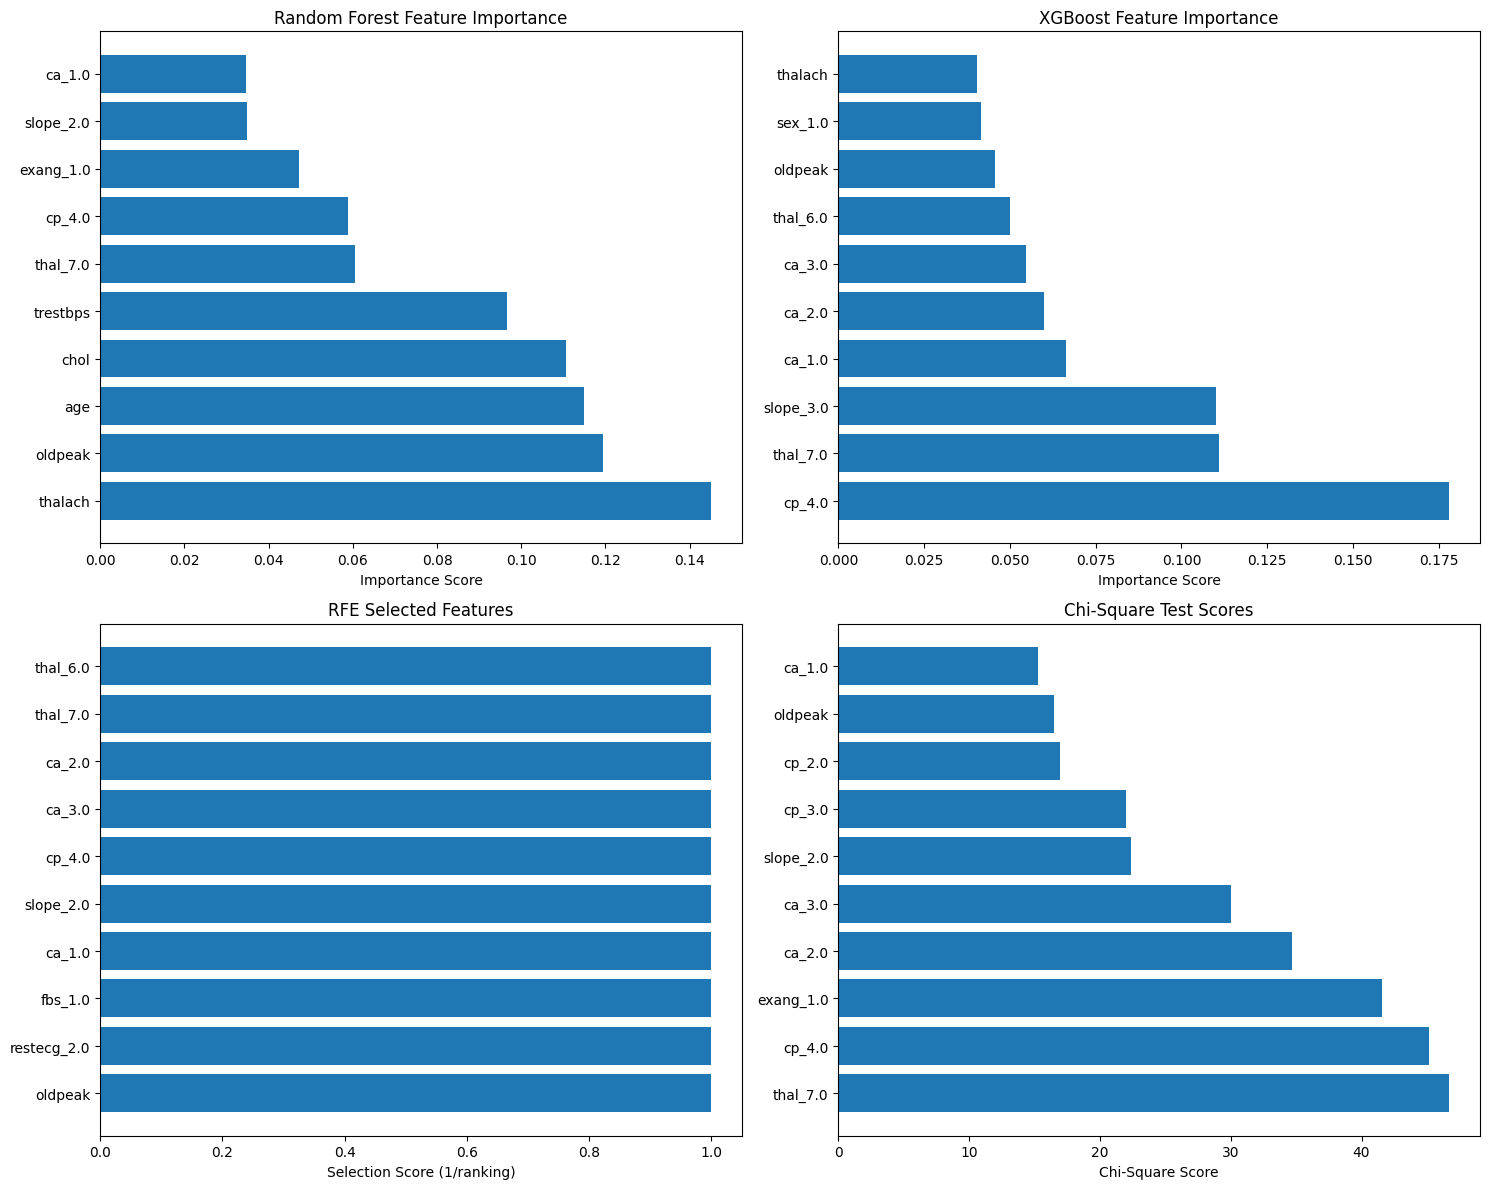

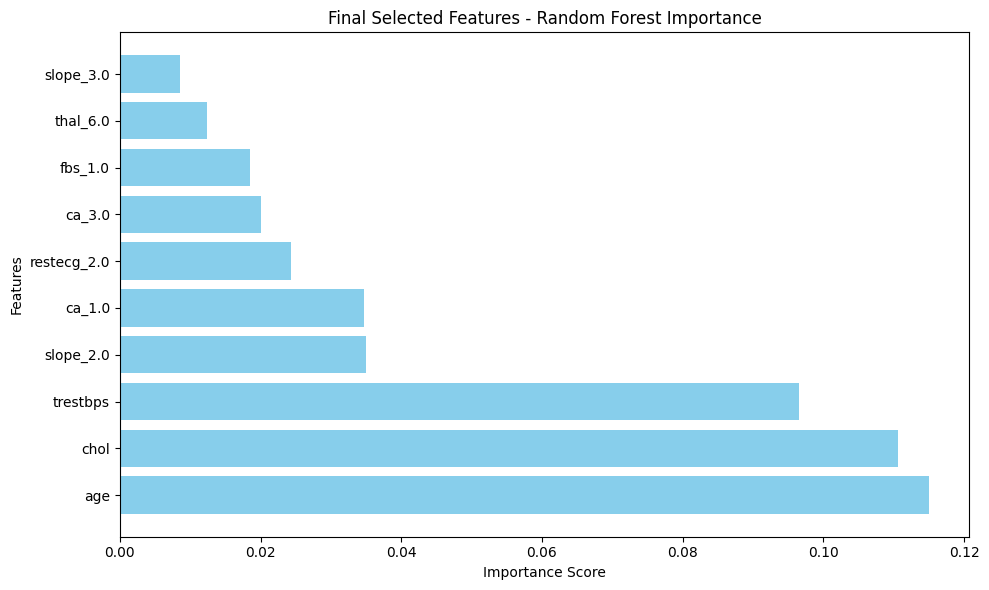

Final selected features: 10 features
1. thal_6.0
2. restecg_2.0
3. slope_2.0
4. fbs_1.0
5. trestbps
6. slope_3.0
7. ca_1.0
8. ca_3.0
9. chol
10. age
Data shape: (303, 10)


In [1]:
%run " 03_feature_selection.ipynb"

X_data = X_selected
y_data = y
print(f"Data shape: {X_data.shape}")

# Elbow Method for Optimal K

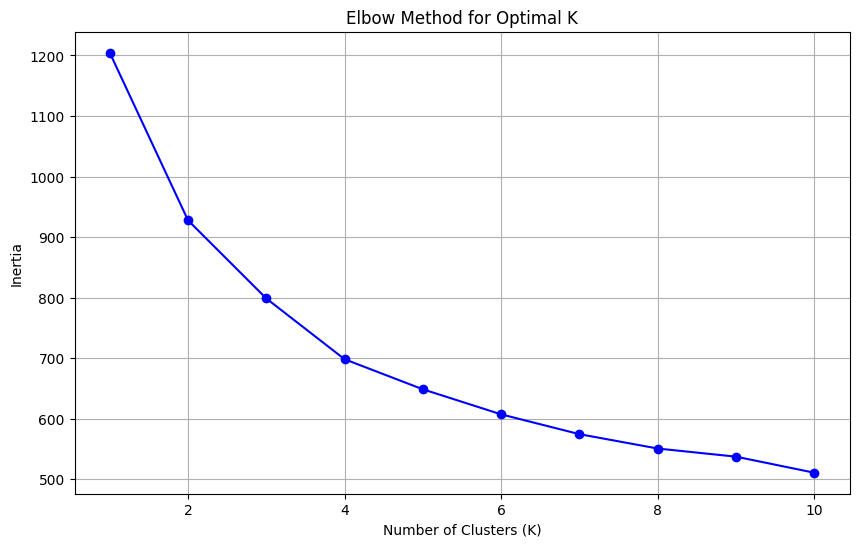

In [2]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import numpy as np

inertias = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_data)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(k_range, inertias, 'bo-')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal K')
plt.grid(True)
plt.show()

# Apply K-Means Clustering

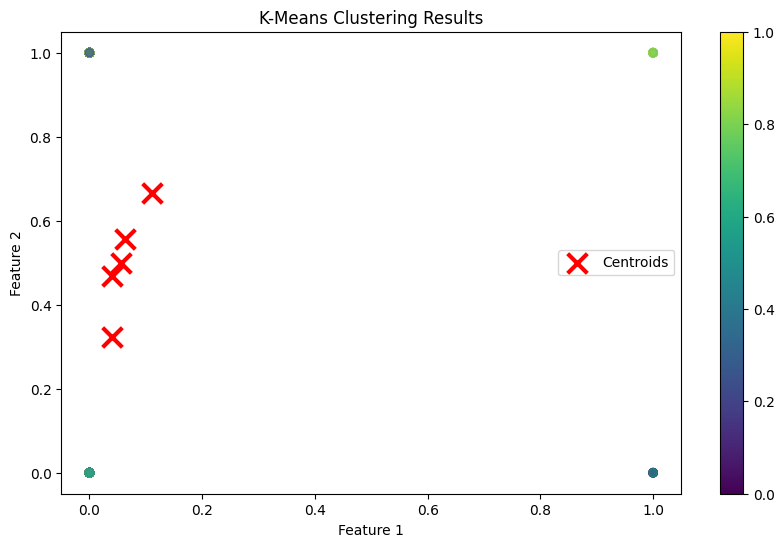

K-Means with 5 clusters completed


In [3]:
optimal_k = 5
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
kmeans_labels = kmeans.fit_predict(X_data)

plt.figure(figsize=(10, 6))
plt.scatter(X_data[:, 0], X_data[:, 1], c=kmeans_labels, cmap='viridis', alpha=0.7)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], 
           c='red', marker='x', s=200, linewidths=3, label='Centroids')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('K-Means Clustering Results')
plt.legend()
plt.colorbar()
plt.show()

print(f"K-Means with {optimal_k} clusters completed")

# Hierarchical Clustering

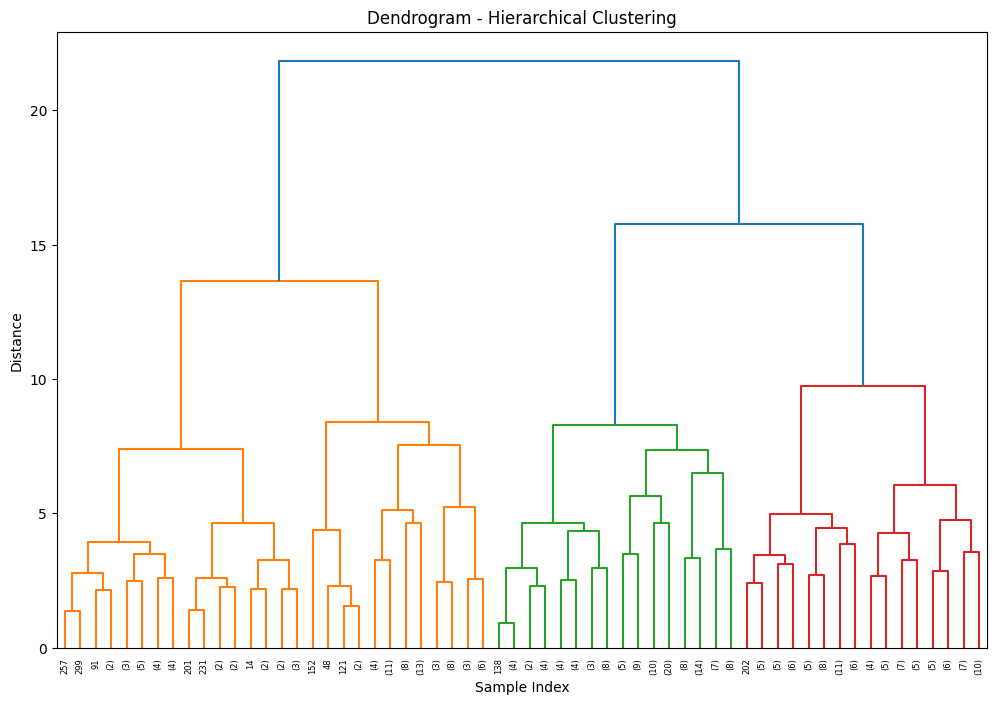

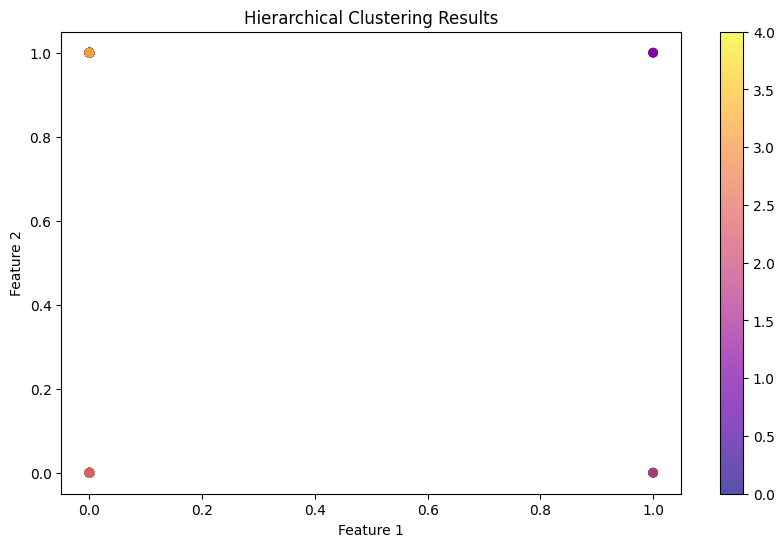

In [4]:
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering

linkage_matrix = linkage(X_data, method='ward')

plt.figure(figsize=(12, 8))
dendrogram(linkage_matrix, truncate_mode='level', p=5)
plt.xlabel('Sample Index')
plt.ylabel('Distance')
plt.title('Dendrogram - Hierarchical Clustering')
plt.show()

hierarchical = AgglomerativeClustering(n_clusters=optimal_k)
hierarchical_labels = hierarchical.fit_predict(X_data)

plt.figure(figsize=(10, 6))
plt.scatter(X_data[:, 0], X_data[:, 1], c=hierarchical_labels, cmap='plasma', alpha=0.7)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Hierarchical Clustering Results')
plt.colorbar()
plt.show()

# Compare Clusters with Disease Labels

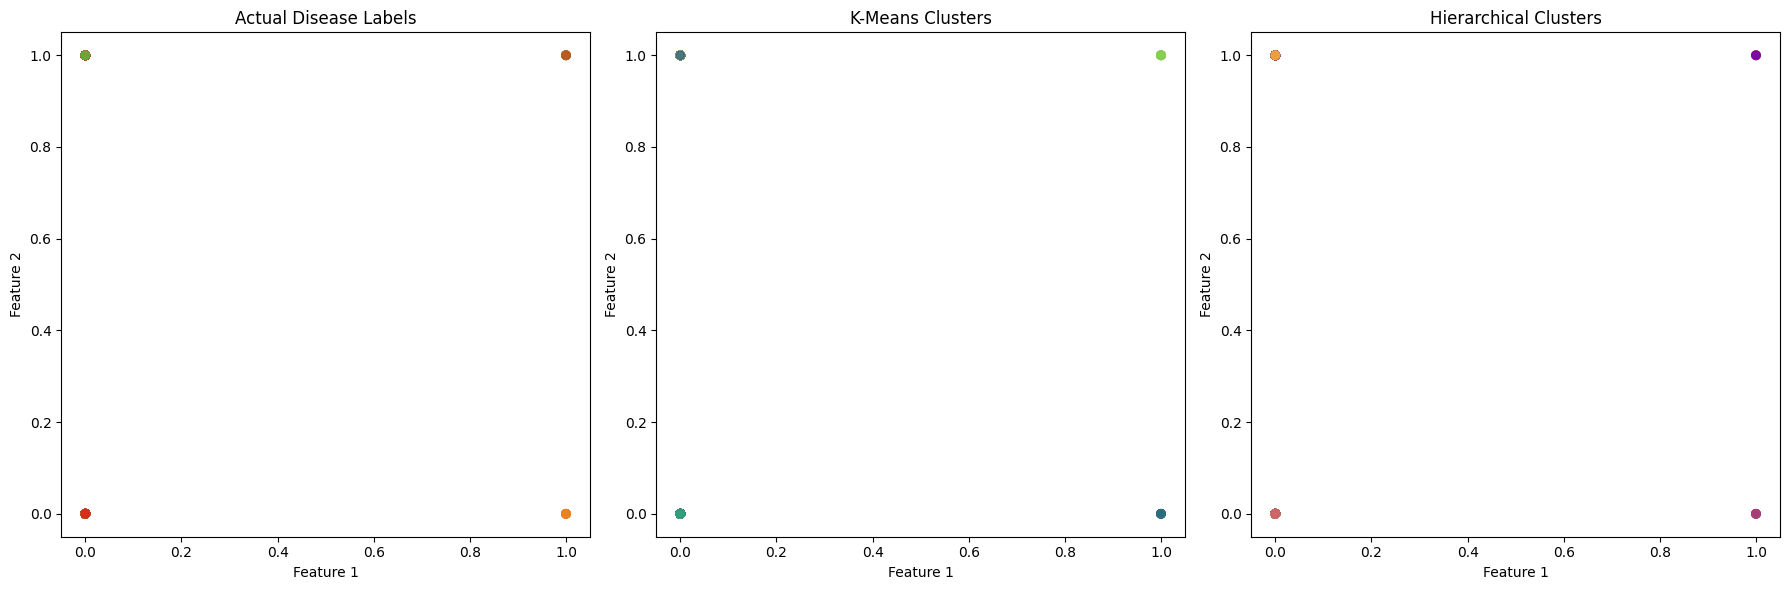

Clustering Performance Comparison:
K-Means vs Actual - ARI: 0.036
K-Means vs Actual - Homogeneity: 0.045
K-Means vs Actual - Completeness: 0.036
Hierarchical vs Actual - ARI: 0.087
Hierarchical vs Actual - Homogeneity: 0.046
Hierarchical vs Actual - Completeness: 0.039


In [5]:
from sklearn.metrics import adjusted_rand_score, homogeneity_score, completeness_score

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].scatter(X_data[:, 0], X_data[:, 1], c=y_data, cmap='Set1', alpha=0.7)
axes[0].set_title('Actual Disease Labels')
axes[0].set_xlabel('Feature 1')
axes[0].set_ylabel('Feature 2')

axes[1].scatter(X_data[:, 0], X_data[:, 1], c=kmeans_labels, cmap='viridis', alpha=0.7)
axes[1].set_title('K-Means Clusters')
axes[1].set_xlabel('Feature 1')
axes[1].set_ylabel('Feature 2')

axes[2].scatter(X_data[:, 0], X_data[:, 1], c=hierarchical_labels, cmap='plasma', alpha=0.7)
axes[2].set_title('Hierarchical Clusters')
axes[2].set_xlabel('Feature 1')
axes[2].set_ylabel('Feature 2')

plt.tight_layout()
plt.show()

print("Clustering Performance Comparison:")
print(f"K-Means vs Actual - ARI: {adjusted_rand_score(y_data, kmeans_labels):.3f}")
print(f"K-Means vs Actual - Homogeneity: {homogeneity_score(y_data, kmeans_labels):.3f}")
print(f"K-Means vs Actual - Completeness: {completeness_score(y_data, kmeans_labels):.3f}")

print(f"Hierarchical vs Actual - ARI: {adjusted_rand_score(y_data, hierarchical_labels):.3f}")
print(f"Hierarchical vs Actual - Homogeneity: {homogeneity_score(y_data, hierarchical_labels):.3f}")
print(f"Hierarchical vs Actual - Completeness: {completeness_score(y_data, hierarchical_labels):.3f}")